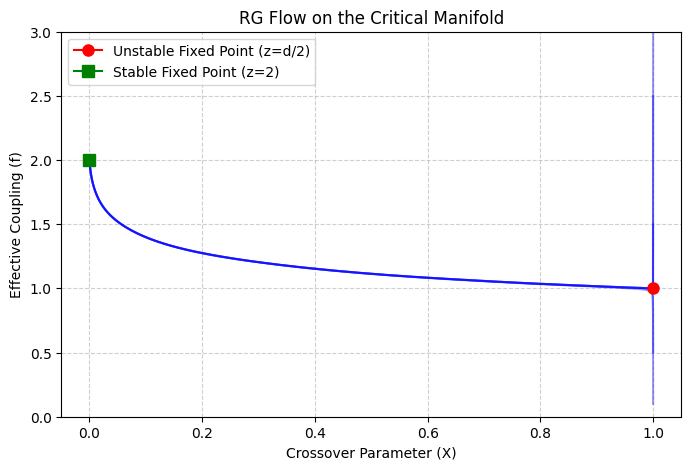

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. DEFINE THE DIFFERENTIAL EQUATIONS
def rg_flow(time, state):
    # Unpack our three changing variables
    f = state[0]
    w = state[1]
    R = state[2]

    epsilon = 1.0  # Because d=3, epsilon = 4-d = 1

    # Calculate X based on current R and w
    X = (R**2 * (1 + w)) / (1 + R**2 * (1 + w))

    # Calculate the rate of change for each variable
    df = f * (epsilon - f * (0.5 + 2 * X / (1 + w)))
    dw = -w * f * (0.5 - 2 * X / (1 + w))
    dR = -R * (1 - 0.25 * f)

    # Return the rates of change as a list
    return [df, dw, dR]

# 2. SET UP THE PLOT
plt.figure(figsize=(8, 5))

# 3. SOLVE AND PLOT TRAJECTORIES
# We loop through a few starting values for f to create multiple lines
f_starting_values = [0.1, 0.5, 1.5, 2.5, 3.0]
w_start = 3.0  # Standard starting value for w

# First batch of lines: Starting near X = 1 (Conservative regime)
# To get X close to 1, we need a very large initial R
R_start_large = 1000.0

for f_start in f_starting_values:
    initial_state = [f_start, w_start, R_start_large]

    # solve_ivp calculates the flow.
    # [0, 20] is the "time" span. t_eval asks for 500 smooth data points.
    solution = solve_ivp(rg_flow, [0, 20], initial_state, t_eval=np.linspace(0, 20, 500))

    # Extract the simulated data
    f_path = solution.y[0]
    w_path = solution.y[1]
    R_path = solution.y[2]

    # Convert R and w paths into the X path for the plot
    X_path = (R_path**2 * (1 + w_path)) / (1 + R_path**2 * (1 + w_path))

    # Plot this specific line in blue
    plt.plot(X_path, f_path, color='blue', alpha=0.4)

# 4. PLOT THE FIXED POINTS
# Mark the Unstable Fixed Point (Conservative)
plt.plot(1.0, 1.0, marker='o', color='red', markersize=8, label="Unstable Fixed Point (z=d/2)")

# Mark the Stable Fixed Point (Dissipative)
plt.plot(0.0, 2.0, marker='s', color='green', markersize=8, label="Stable Fixed Point (z=2)")

# 5. CLEAN UP THE VISUALS
plt.xlim(-0.05, 1.05)
plt.ylim(0, 3)
plt.xlabel("Crossover Parameter (X)")
plt.ylabel("Effective Coupling (f)")
plt.title("RG Flow on the Critical Manifold")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

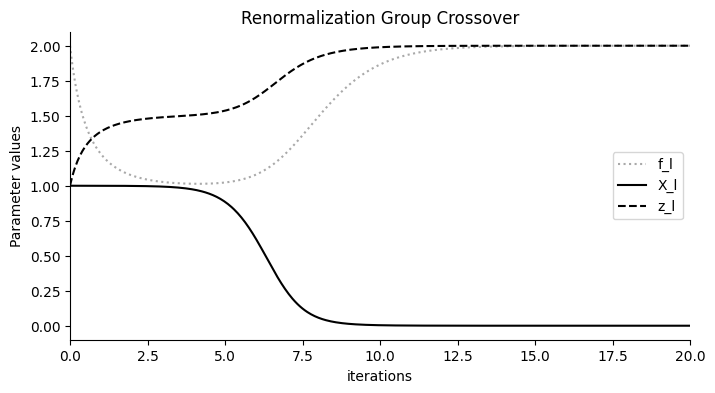

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. Define the differential equations
def rg_flow(y, x):
    # Unpack the current values of our variables
    f, w, R = y

    # Epsilon is 4 - d. For 3-dimensional space, epsilon = 1
    epsilon = 1.0

    # Calculate X based on R and w (assuming Lambda = 1)
    X = (R**2 * (1 + w)) / (1 + R**2 * (1 + w))

    # The flow equations (how the variables change at each step)
    df_dx = f * (epsilon - f * (0.5 + 2 * X / (1 + w)))
    dw_dx = -w * f * (0.5 - 2 * X / (1 + w))
    dR_dx = -R * (1 - f / 4.0)

    # Return the rates of change
    return [df_dx, dw_dx, dR_dx]

# 2. Set up the initial conditions (given in the paper's caption)
f0 = 2.0
w0 = 3.0
X0 = 0.9999

# Solve for initial R0 using the formula for X0
K = X0 / (1.0 - X0)
R0 = np.sqrt(K / (1.0 + w0))

initial_conditions = [f0, w0, R0]

# 3. Create the x-axis (from 0 to 20 iterations, 500 smooth steps)
x_values = np.linspace(0, 20, 500)

# 4. Solve the differential equations using odeint
solution = odeint(rg_flow, initial_conditions, x_values)

# Extract the solved variables over time
f_vals = solution[:, 0]
w_vals = solution[:, 1]
R_vals = solution[:, 2]

# 5. Calculate X_l and z_l for plotting
X_vals = (R_vals**2 * (1 + w_vals)) / (1 + R_vals**2 * (1 + w_vals))
z_vals = 2.0 - (2.0 * f_vals / (1.0 + w_vals)) * X_vals

# 6. Plot the results to match Figure 1
plt.figure(figsize=(8, 4))

# Plot f_l, X_l, and z_l with styles resembling the paper
plt.plot(x_values, f_vals, label='f_l', color='darkgray', linestyle=':')
plt.plot(x_values, X_vals, label='X_l', color='black', linestyle='-')
plt.plot(x_values, z_vals, label='z_l', color='black', linestyle='--')

# Formatting the plot
plt.xlabel('iterations')
plt.ylabel('Parameter values')
plt.xlim(0, 20)
plt.ylim(-0.1, 2.1)
plt.legend(loc='center right')
plt.title('Renormalization Group Crossover')

# Remove top and right spines to make it look like a scientific paper
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

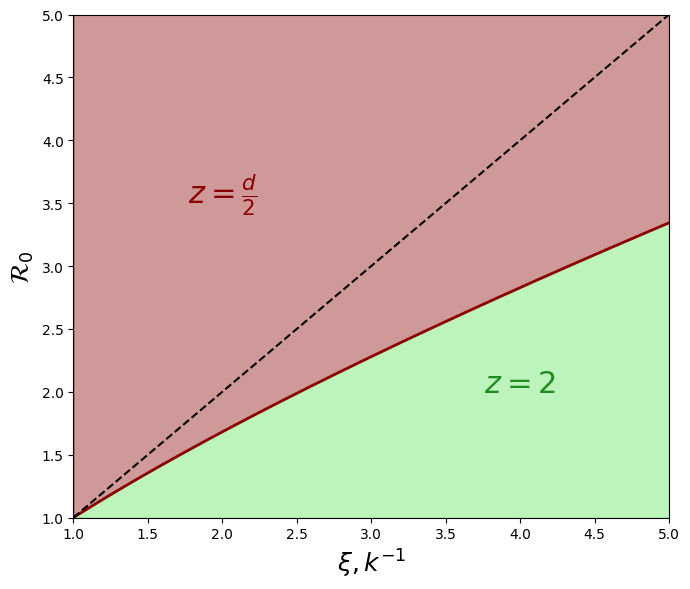

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the spatial dimension
d = 3

# 2. Create the x-axis values (length scale L, which is xi or k^-1)
x = np.linspace(1, 5, 500)

# 3. Calculate the main boundary curve: y = x^(d/4)
y_curve = x**(d / 4.0)

# 4. Calculate the dashed line: y = x
y_dashed = x

# 5. Set up the plot canvas
plt.figure(figsize=(7, 6))

# 6. Fill the "conservative" region (dark red) above the curve
# We fill from the curve up to the top limit of the plot (y=5)
plt.fill_between(x, y_curve, 5, color='darkred', alpha=0.4)

# 7. Fill the "dissipative" region (light green) below the curve
# We fill from the bottom limit of the plot (y=1) up to the curve
plt.fill_between(x, 1, y_curve, color='lightgreen', alpha=0.6)

# 8. Plot the separating curve and the dashed line
plt.plot(x, y_curve, color='darkred', linewidth=2)
plt.plot(x, y_dashed, color='black', linestyle='--', linewidth=1.5)

# 9. Add text labels inside the regions
# The 'r' before the string lets us use standard mathematical formatting
plt.text(2, 3.5, r'$z = \frac{d}{2}$', fontsize=22, color='darkred', ha='center')
plt.text(4, 2, r'$z = 2$', fontsize=22, color='forestgreen', ha='center')

# 10. Format the axes and labels
plt.xlim(1, 5)
plt.ylim(1, 5)
plt.xlabel(r'$\xi, k^{-1}$', fontsize=18)
plt.ylabel(r'$\mathcal{R}_0$', fontsize=18)

# 11. Finalize and show the plot
plt.tight_layout()
plt.show()